In [6]:
print(df.columns.tolist())

['Year', 'Question', 'Demographics_Type', 'Demographics_Value', 'Percent', 'Low_Confidence_Interval', 'High_Confidence_Interval', 'Confidence_Interval_Formatted', 'Data_Source']


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mentalHealth_.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())


(566, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Year                           566 non-null    object
 1   Question                       566 non-null    object
 2   Demographics_Type              566 non-null    object
 3   Demographics_Value             566 non-null    object
 4   Percent                        566 non-null    object
 5   Low_Confidence_Interval        566 non-null    object
 6   High_Confidence_Interval       566 non-null    object
 7   Confidence_Interval_Formatted  566 non-null    object
 8   Data_Source                    566 non-null    object
dtypes: object(9)
memory usage: 39.9+ KB
None
Year                             0
Question                         0
Demographics_Type                0
Demographics_Value               0
Percent                          0
Low_Confidence_In

In [8]:
anxiety = df[
    (df["Question"].str.contains("anxiety disorder", case=False)) &
    (df["Demographics_Type"] == "Total")
].copy()

anxiety = anxiety.sort_values("Year")

print(anxiety[["Year", "Percent"]])

     Year Percent
389  2019    14.1
376  2020    15.1
363  2021    16.4
350  2022    17.8
337  2023    18.5
324  2024    18.5


In [11]:
anxiety["Percent"] = pd.to_numeric(
    anxiety["Percent"],
    errors="coerce"
)

first = anxiety.iloc[0]["Percent"]
last = anxiety.iloc[-1]["Percent"]

change = last - first

print(
    "Change from 2019 to 2024:",
    round(change, 2),
    "percentage points"
)

Change from 2019 to 2024: 4.4 percentage points


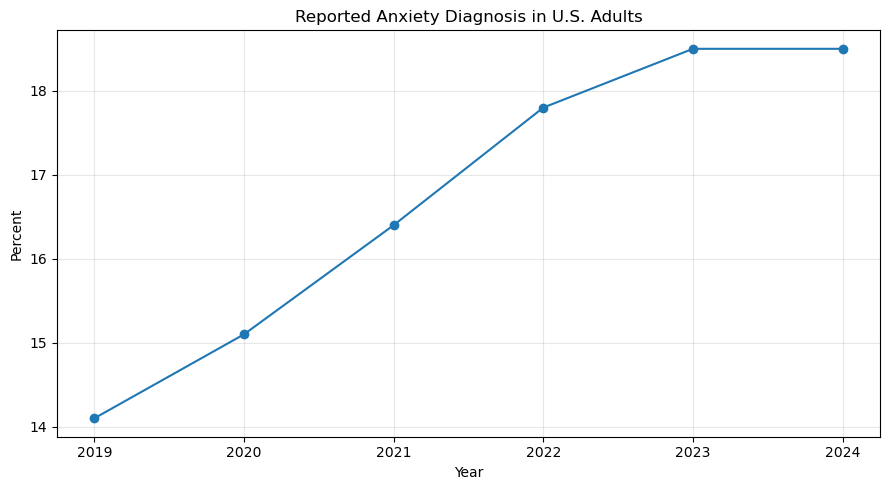

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    anxiety["Year"],
    anxiety["Percent"],
    marker="o"
)

plt.title("Reported Anxiety Diagnosis in U.S. Adults")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()